In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [64]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [65]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [66]:
df.rename(columns={'who':'gender'},inplace= True)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,gender,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [67]:
df = df.drop(columns=['embark_town','deck','alone','adult_male','alive'], axis = 1)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,gender
0,0,3,male,22.0,1,0,7.2500,S,Third,man
1,1,1,female,38.0,1,0,71.2833,C,First,woman
2,1,3,female,26.0,0,0,7.9250,S,Third,woman
3,1,1,female,35.0,1,0,53.1000,S,First,woman
4,0,3,male,35.0,0,0,8.0500,S,Third,man


In [68]:
df = pd.get_dummies(df, columns=['embarked','sex','class'],drop_first= True)
df.head()

,survived,pclass,age,sibsp,parch,fare,gender,embarked_Q,embarked_S,sex_male,class_Second,class_Third
0,0,3,22.0,1,0,7.2500,man,False,True,True,False,True
1,1,1,38.0,1,0,71.2833,woman,False,False,False,False,False
2,1,3,26.0,0,0,7.9250,woman,False,True,False,False,True
3,1,1,35.0,1,0,53.1000,woman,False,True,False,False,False
4,0,3,35.0,0,0,8.0500,man,False,True,True,False,True


In [69]:
df['age'] = df['age'].fillna(df['age'].mean())
print('Shape', df.shape)

Shape (891, 12)


In [70]:
x = df.drop(columns=['survived','fare','gender'])
y = df['survived']

In [71]:
x_train,x_test, y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=24)


In [72]:
model = DecisionTreeClassifier(max_depth=6, random_state=24)
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,24
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [74]:
y_pred = model.predict(x_test)
y_pred

array([0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1])

In [75]:
print('accuracy_score:',accuracy_score(y_test,y_pred))


accuracy_score: 0.8156424581005587


In [80]:
print('Confusion Matrix:\n', confusion_matrix(y_test,y_pred))

Confusion Matrix:
 [[103  14]
 [ 19  43]]


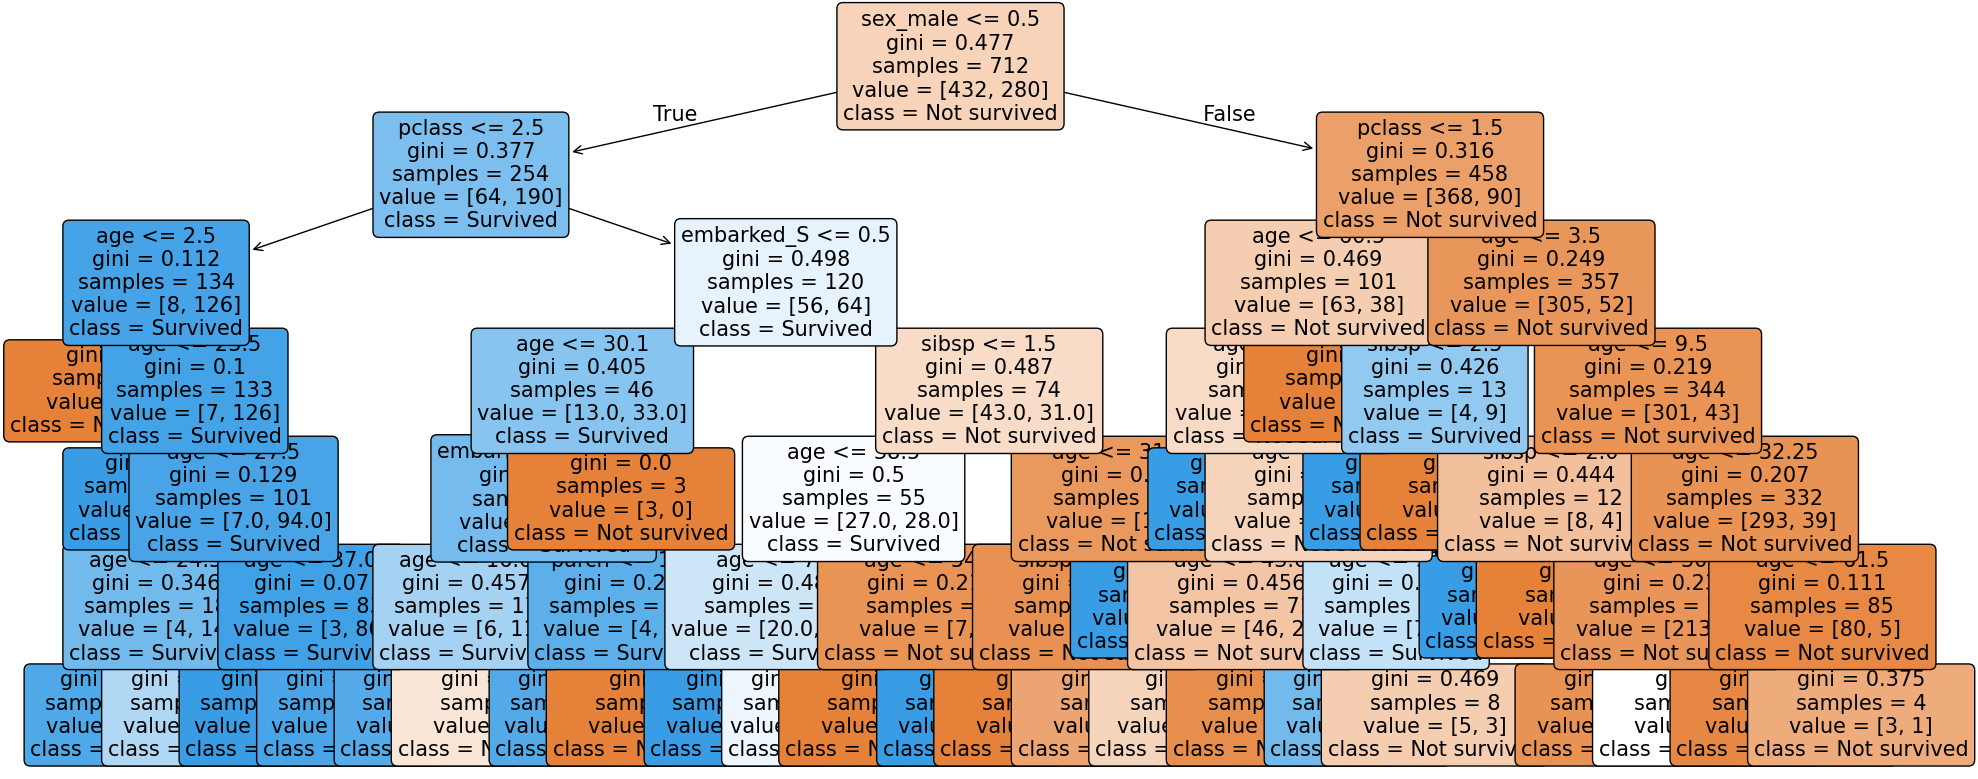

In [88]:
plt.figure(figsize=(20,8))
plot_tree(model,feature_names=x.columns,
          class_names=['Not survived','Survived'],
          filled=True,
          fontsize=15,
          rounded=True

          
          )
plt.tight_layout()
plt.show()